# Per-Attack Category Analysis

**Research questions addressed:**  
> RQ3: For which attack types does eBPF help the most?

This notebook uses only the **saved Split 4 realistic headline artifacts** from Notebook 01. It is therefore limited to the attack families that actually appear in the Friday realistic holdout; absent families are not evaluated here and must not be discussed as if they were tested.


In [1]:
import os, sys, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tracemalloc

HERE = Path.cwd().resolve()
REPO_ROOT = None
for _p in [HERE] + list(HERE.parents):
    if (_p / 'ml').exists() and (_p / 'data').exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from ml.notebooks.experiment_config import *
from ml.notebooks.modeling_pipeline import load_model_pack, prepare_split, align_to_features, per_attack_detection_rates

PACKS = {
    'baseline': load_model_pack('baseline', artifact='headline', seed=RANDOM_SEED),
    'ebpf': load_model_pack('ebpf', artifact='headline', seed=RANDOM_SEED),
}

DATA = {}
for fs, split4 in [('baseline', SPLITS_4_BASELINE), ('ebpf', SPLITS_4_EBPF)]:
    te_df = pd.read_parquet(split4 / 'test_realistic.parquet')
    prep = prepare_split(te_df, feature_list=PACKS[fs]['features'])
    X = align_to_features(prep.X, PACKS[fs]['features'])
    DATA[fs] = {'X': X, 'y': prep.y, 'labels': prep.labels}
    print(f"[*] {fs}: model={PACKS[fs]['selected_model_name']} rows={len(X):,}")


[*] baseline: model=hgb_balanced rows=546,207
[*] ebpf: model=hgb_balanced rows=546,207


## Load saved headline artifacts and Split 4 realistic test data

The Friday realistic holdout contains only `Bot`, `DDoS`, and `PortScan` attack families. The stored headline artifact threshold is reused exactly so the per-attack tables stay consistent with the headline operating point.


In [ ]:
attack_support = (
    pd.DataFrame({'attack': DATA['baseline']['labels']})
      .query("attack != 'BENIGN'")
      .value_counts()
      .rename('n')
      .reset_index()
      .sort_values('n', ascending=False)
      .reset_index(drop=True)
)
print('[*] Attack families present in Split 4 realistic:')
print(attack_support.to_string(index=False))

attack_tables = {}
for fs in ['baseline', 'ebpf']:
    model = PACKS[fs]['model']
    d = DATA[fs]
    stored_thr = PACKS[fs].get('threshold', None)
    print(f"\n[*] {fs} headline artifact")
    print(f"    model={PACKS[fs].get('selected_model_name')} threshold_mode={PACKS[fs].get('threshold_mode')} threshold={stored_thr:.6f}")
    if PACKS[fs].get('target_recall') is not None:
        print(f"    target_recall={PACKS[fs]['target_recall']:.4f}")

    if stored_thr is not None and hasattr(model, 'predict_proba'):
        prob = model.predict_proba(d['X'])[:, 1]
        y_pred = (prob >= stored_thr).astype(int)
        rows_tbl = []
        BENIGN_LIKE = {"BENIGN", "Unknown", "nan", "NaN", ""}
        for attack in sorted(d['labels'].unique()):
            if attack in BENIGN_LIKE:
                continue
            mask = (d['labels'] == attack).to_numpy()
            n = int(mask.sum())
            if n == 0:
                continue
            det = int((y_pred[mask] == 1).sum())
            rows_tbl.append({
                'attack': attack,
                'n': n,
                'detected': det,
                'detection_rate': float(det / max(n, 1)),
            })
        tbl = pd.DataFrame(rows_tbl).sort_values('attack').reset_index(drop=True)
    else:
        tbl = per_attack_detection_rates(model, d['X'], d['labels'])
        print('    [!] Pack did not contain a stored threshold; fell back to model.predict().')
    attack_tables[fs] = tbl
    print(tbl.to_string(index=False, float_format='{:.4f}'.format))

merged = attack_tables['baseline'].merge(
    attack_tables['ebpf'][['attack', 'detection_rate']],
    on='attack', how='outer', suffixes=('_baseline', '_ebpf')
).fillna(0)
merged['delta'] = merged['detection_rate_ebpf'] - merged['detection_rate_baseline']
merged = merged.sort_values('delta', ascending=False)

print('\n[*] Delta detection rate (ebpf - baseline)')
print(merged[['attack', 'detection_rate_baseline', 'detection_rate_ebpf', 'delta']].to_string(index=False, float_format='{:+.4f}'.format))

merged.to_csv(REPORTS_DIR / f'per_attack_delta_headline_model_seed{RANDOM_SEED}.csv', index=False)


[*] Attack families present in Split 4 realistic:
  attack      n
PortScan 159109
    DDoS  86636
     Bot   2208

[*] baseline headline artifact
    model=hgb_balanced threshold_mode=matched_recall threshold=0.000856
    target_recall=0.5810
  attack      n  detected  detection_rate
     Bot   2208         0          0.0000
    DDoS  86636     86624          0.9999
PortScan 159109      4614          0.0290

[*] ebpf headline artifact
    model=hgb_balanced threshold_mode=matched_recall threshold=0.000447
    target_recall=0.5810
  attack      n  detected  detection_rate
     Bot   2208         0          0.0000
    DDoS  86636     86635          1.0000
PortScan 159109      4476          0.0281

[*] Delta detection rate (ebpf - baseline)
  attack  detection_rate_baseline  detection_rate_ebpf   delta
    DDoS                  +0.9999              +1.0000 +0.0001
     Bot                  +0.0000              +0.0000 +0.0000
PortScan                  +0.0290              +0.0281 -0.0009


## Per-attack detection rates

Interpret these bars conservatively:
- `DDoS` dominates the positive class and both models detect it almost perfectly.
- `PortScan` remains weak for both models.
- `Bot` remains essentially undetected in this setup.

Small deltas on rare or poorly detected families should not be overclaimed.


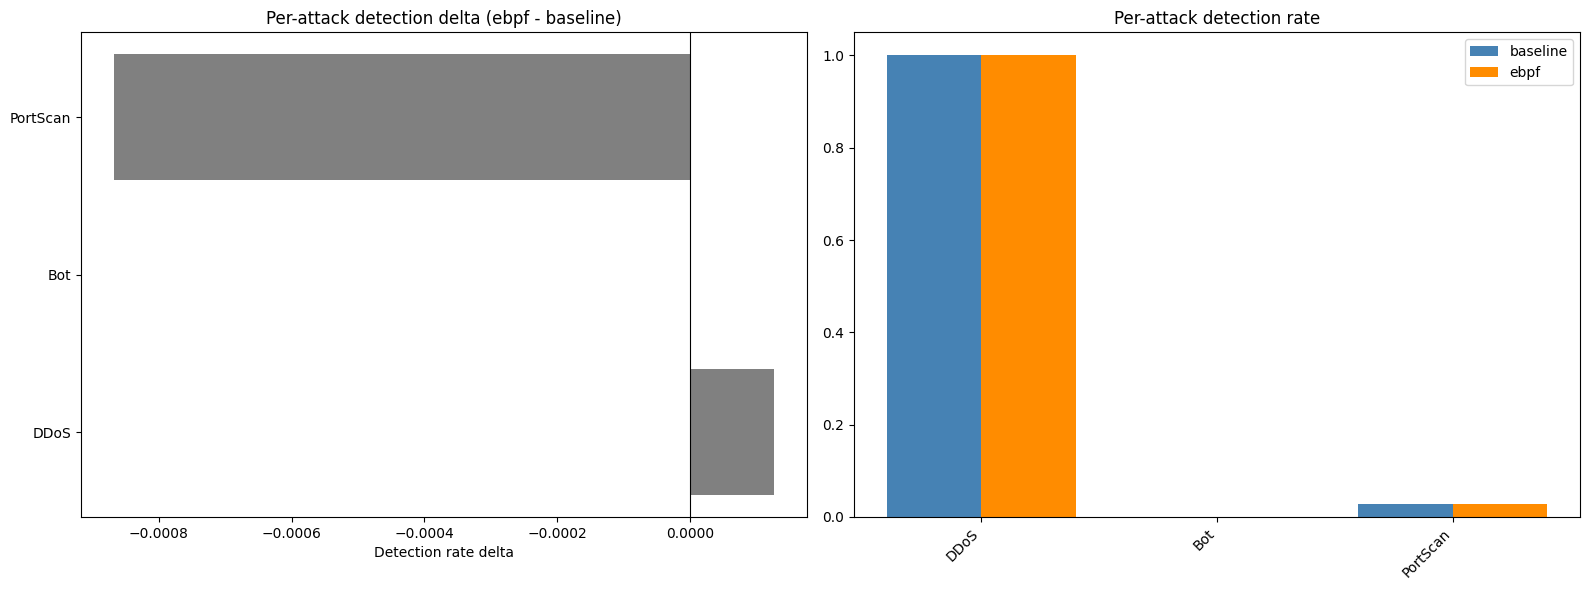

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Delta chart
colors = ['darkorange' if x > 0.01 else ('steelblue' if x < -0.01 else 'grey') for x in merged['delta']]
axes[0].barh(merged['attack'], merged['delta'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Per-attack detection delta (ebpf - baseline)')
axes[0].set_xlabel('Detection rate delta')

# Side-by-side rates
attacks = merged['attack'].tolist()
x = np.arange(len(attacks))
w = 0.4
bmap = dict(zip(merged['attack'], merged['detection_rate_baseline']))
emap = dict(zip(merged['attack'], merged['detection_rate_ebpf']))
axes[1].bar(x - w/2, [bmap[a] for a in attacks], w, label='baseline', color='steelblue')
axes[1].bar(x + w/2, [emap[a] for a in attacks], w, label='ebpf', color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(attacks, rotation=45, ha='right')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Per-attack detection rate')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / f'per_attack_plots_headline_model_seed{RANDOM_SEED}.png', dpi=150)
plt.show()


## Canonical overhead reference

In [4]:
overheads_path = REPORTS_DIR / 'overheads' / 'overheads.json'
if overheads_path.exists():
    overheads = json.loads(overheads_path.read_text())
    proto = overheads.get('benchmark_protocol', {})
    models_df = pd.DataFrame(overheads.get('models', []))
    print('[*] Canonical overhead protocol')
    print(json.dumps(proto, indent=2))
    if not models_df.empty:
        show_cols = [
            'dataset', 'model', 'artifact_load_seconds', 'latency_mean_seconds',
            'latency_std_seconds', 'infer_ms_per_1k', 'infer_rows_benchmarked',
            'latency_repeats', 'model_size_bytes', 'test_auc', 'test_ap',
        ]
        show_cols = [c for c in show_cols if c in models_df.columns]
        print(models_df[show_cols].to_string(index=False, float_format='{:.4f}'.format))
    else:
        print('[!] Overhead artifact exists but contains no model rows.')
else:
    print(f'[!] Canonical overhead report not found: {overheads_path}')


[*] Canonical overhead protocol
{
  "train_load_measurement": "wall_clock_seconds_to_read_train_parquet",
  "test_load_measurement": "wall_clock_seconds_to_read_requested_test_parquet",
  "inference_measurement": "saved-artifact scoring latency on a fixed first-N-row sample after one warmup pass; reported as mean/std seconds and ms per 1k rows",
  "test_file": "test_realistic",
  "infer_sample_n": 10000,
  "infer_repeats": 7,
  "skip_training": true
}
 dataset        model  artifact_load_seconds  latency_mean_seconds  latency_std_seconds  infer_ms_per_1k  infer_rows_benchmarked  latency_repeats  model_size_bytes  test_auc  test_ap
baseline hgb_balanced                 0.4661                0.0481               0.0053           4.8112                   10000                7           1113173    0.9202   0.8575
    ebpf hgb_balanced                 0.3537                0.0537               0.0398           5.3688                   10000                7           1117911    0.7115   0.